In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import(
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.base import clone
from sklearn.metrics import recall_score


In [ ]:
!wget -q https://archive.ics.uci.edu/static/public/320/student+performance.zip

In [ ]:
import zipfile

with zipfile.ZipFile("student+performance.zip", "r") as zip_ref:
    print(zip_ref.namelist())

['.student.zip_old', 'student.zip']


In [ ]:
import zipfile

with zipfile.ZipFile("student.zip", "r") as zip_ref:
    print(zip_ref.namelist())

['student-mat.csv', 'student-por.csv', 'student-merge.R', 'student.txt']


In [ ]:
!unzip -o "student+performance.zip"

Archive:  student+performance.zip
 extracting: .student.zip_old        
 extracting: student.zip             


In [ ]:
!ls

sample_data   student+performance.zip	 student.zip
student_data  student+performance.zip.1


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [ ]:
import os
print(os.getcwd())
print(os.listdir())

/content
['.config', 'student_data', 'student+performance.zip', 'student.zip', '.student.zip_old', 'student+performance.zip.1', 'sample_data']


In [ ]:
import zipfile

zip_path = "/content/student+performance.zip"

with zipfile.ZipFile(zip_path, "r") as z:
    print("Files inside the ZIP:")
    for file in z.namelist():
        print(file)

Files inside the ZIP:
.student.zip_old
student.zip


In [ ]:
import zipfile

zip_path = "/content/student.zip"

with zipfile.ZipFile(zip_path, "r") as z:
    print("Files inside student.zip:")
    for file in z.namelist():
        print(file)

Files inside student.zip:
student-mat.csv
student-por.csv
student-merge.R
student.txt


In [ ]:
import zipfile

zip_path = "/content/student.zip"

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall("/content/student_data")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
import os

print(os.listdir("/content/student_data"))

['student-merge.R', 'student-mat.csv', 'student-por.csv', 'student.txt']


In [ ]:
import pandas as pd

df = pd.read_csv(
    "/content/student_data/student-mat.csv",
    sep=";"
)

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [ ]:
print(df.shape)

(395, 33)


In [ ]:
print(df.isnull().sum())

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


In [ ]:
print(df.columns)

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [ ]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [ ]:
print(df.duplicated().sum())

0


In [ ]:
df["G3"].value_counts().sort_index()

,count
G3,
0,38
4,1
5,7
6,15
7,9
8,32
9,28
10,56
11,47


In [ ]:
print(df["G3"].min())
print(df["G3"].max())
print(df["G3"].mean())
print(df["G3"].median())

0
20
10.415189873417722
11.0


In [ ]:
pass_fail=np.where(df["G3"]>10,"pass","fail")
pd.Series(pass_fail).value_counts()

,count
pass,209
fail,186


In [ ]:
df["pass_fail"]=np.where(df["G3"]>=10,"pass","fail")
print(df[["G3","pass_fail"]].head())

   G3 pass_fail
0   6      fail
1   6      fail
2  10      pass
3  15      pass
4  10      pass


In [ ]:
print("pass_fail" in df.columns)

True


In [ ]:
df[["G1","G2","G3"]].corr()

,G1,G2,G3
G1,1.000000,0.852118,0.801468
G2,0.852118,1.000000,0.904868
G3,0.801468,0.904868,1.000000


In [ ]:
sns.set_theme(style="whitegrid")

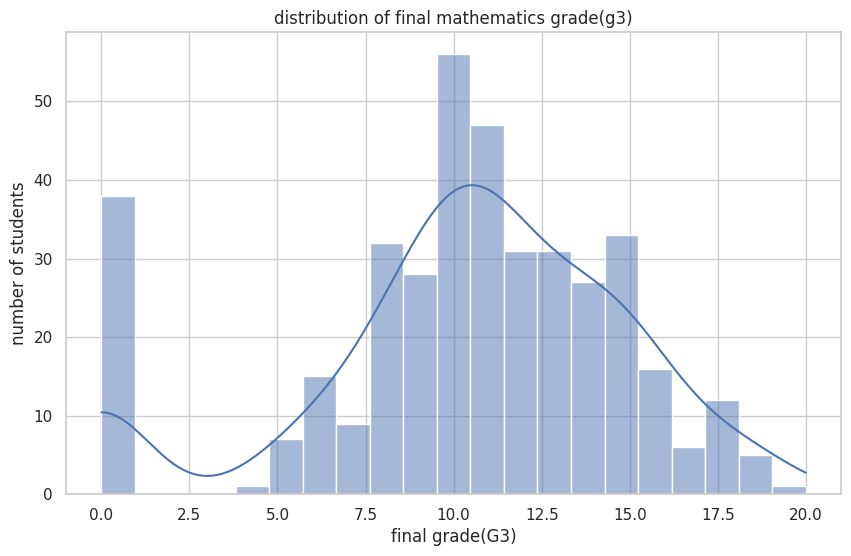

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(
    data=df,
    x="G3",
    bins=21,
    kde=True
)
plt.title("distribution of final mathematics grade(g3)")
plt.xlabel("final grade(G3)")
plt.ylabel("number of students")
plt.show()

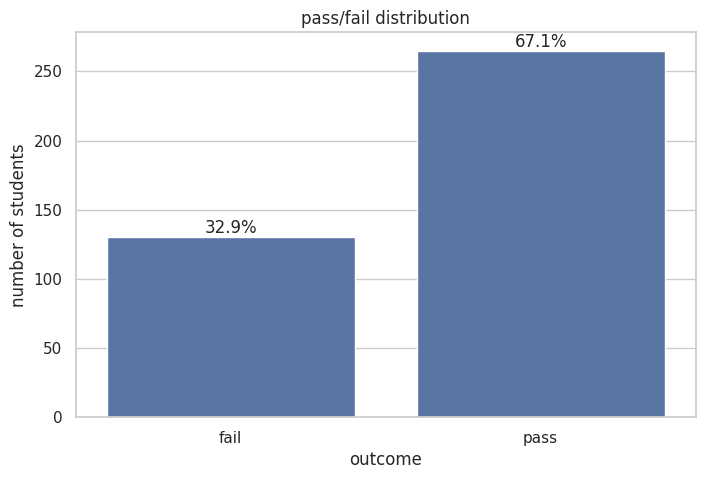

In [ ]:
plt.figure(figsize=(8,5))
ax=sns.countplot(
    data=df,
    x="pass_fail"

)
total=len(df)
for container in ax.containers:
  labels=[
      f"{(value/total)*100:.1f}%"
      for value in container.datavalues
  ]
  ax.bar_label(container,labels=labels)
  plt.title("pass/fail distribution")
  plt.xlabel("outcome")
  plt.ylabel("number of students")
  plt.show()

In [ ]:
print(df.columns.tolist())

['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3', 'pass_fail']


In [ ]:
RANDOM_STATE=42
target_reg="G3"
target_clf="pass_fail"

In [ ]:
df["pass_fail"]=(df["G3"]>=10).astype(int)
print(df[["G3","pass_fail"]].head())

   G3  pass_fail
0   6          0
1   6          0
2  10          1
3  15          1
4  10          1


In [ ]:
all_features=[
    col for col in df.columns
    if col not in["G3","pass_fail"]
]
print("number of feature:",len(all_features))
print(all_features)

number of feature: 32
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']


In [ ]:
early_features=[
    col for col  in all_features
    if col not in ["G1","G2"]
]

In [ ]:
later_features=all_features.copy()

In [ ]:
print(early_features)
print(later_features)

['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']


In [ ]:
numerical_features=[
    "age","absences","Medu","Fedu","traveltime","studytime","failures","famrel","freetime","goout","Dalc","Walc","health"
]
categorical_features=[
    "school","sex","address","famsize","Pstatus","Mjob",
    "Fjob","reason","guardian","schoolsup","famsup","paid","activities","nursery","higher","internet","romantic"
]

In [ ]:
defines_features=numerical_features+categorical_features
print(len(all_features))
print(len(defines_features))
missing_from_definition=set(all_features)-set(defines_features)
print(missing_from_definition)


32
30
{'G1', 'G2'}


In [ ]:
categorical_transformer=Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="if_binary"
            )
        )

    ]
)

In [ ]:
numeric_transformer=Pipeline(
    steps=[
        ("scaler",StandardScaler())
    ]

)

In [ ]:
preprocessor=ColumnTransformer(
    transformers=[
        ("num",numeric_transformer,numerical_features),
        ("cat",categorical_transformer,categorical_features)
    ]
)

In [ ]:
x_reg=df[early_features]
y_reg=df["G3"]


In [ ]:
x_train_reg,x_test_reg,y_train_reg,y_test_reg=train_test_split(
    x_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

In [ ]:
print(x_train_reg.shape)
print(x_test_reg.shape)

(316, 30)
(79, 30)


In [ ]:
def evaluate_regression(model_name,y_true,y_pred):
  mae=mean_absolute_error(y_true,y_pred)
  rmse=np.sqrt(
      mean_squared_error(y_true,y_pred)

  )
  r2=r2_score(y_true,y_pred)
  print({model_name})
  print("-"*40)
  print(f"MAE:{mae:.3f}")
  print(f"RMSE:{rmse:.3f}")
  print(f"R2:{r2:.3f}")
  return{
      "model":model_name,
      "mae":mae,
      "rmse":rmse,
      "r2":r2
  }

In [ ]:
dummy_reg=Pipeline(
    steps=[
        ("preprocessor",preprocessor),
        ("model",DummyRegressor())
    ]
)


In [ ]:
dummy_reg.fit(
    x_train_reg,
    y_train_reg
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'absences', 'Medu',
                                                   'Fedu', 'traveltime',
                                                   'studytime', 'failures',
                                                   'famrel', 'freetime',
                                                   'goout', 'Dalc', 'Walc',
                                                   'health']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(drop='if_binary',
                                                                                 handle_unknown='ignore'))]),
                                                  ['school', 'sex', 'address',
                                                   'famsize', 'Pstatus', 'Mjob',
                                                   'Fjob', 'reason', 'guardian',
                                                   'schoolsup', 'famsup',
                                                   'paid', 'activities',
                                                   'nursery', 'higher',
                                                   'internet', 'romantic'])])),
                ('model', DummyRegressor())])

In [ ]:
dummy_pred=dummy_reg.predict(
    x_test_reg
)

In [ ]:
regression_results=[]
regression_results.append(
    evaluate_regression(
        "Dummy Regressor",
        y_test_reg,
        dummy_pred
    )
)

{'Dummy Regressor'}
----------------------------------------
MAE:3.646
RMSE:4.550
R2:-0.010


In [ ]:
linear_reg=Pipeline(
    steps=[
        ("preprocessor",preprocessor),
        ("model",LinearRegression)
    ]
)

In [ ]:
type(Pipeline)

abc.ABCMeta

In [ ]:
type(LinearRegression)

abc.ABCMeta

In [ ]:
print(type(preprocessor))
print(type(numeric_transformer))
print(type(categorical_transformer))

<class 'sklearn.compose._column_transformer.ColumnTransformer'>
<class 'sklearn.pipeline.Pipeline'>
<class 'sklearn.pipeline.Pipeline'>


In [ ]:
print(preprocessor)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['age', 'absences', 'Medu', 'Fedu',
                                  'traveltime', 'studytime', 'failures',
                                  'famrel', 'freetime', 'goout', 'Dalc', 'Walc',
                                  'health']),
                                ('cat',
                                 Pipeline(steps=[('onehot',
                                                  OneHotEncoder(drop='if_binary',
                                                                handle_unknown='ignore'))]),
                                 ['school', 'sex', 'address', 'famsize',
                                  'Pstatus', 'Mjob', 'Fjob', 'reason',
                                  'guardian', 'schoolsup', 'famsup', 'paid',
                                  'activities', 'nursery', 'higher', 'internet',
                                 

In [ ]:
print(type(StandardScaler))
print(type(OneHotEncoder))
print(type(ColumnTransformer))
print(type(LinearRegression))

<class 'type'>
<class 'type'>
<class 'abc.ABCMeta'>
<class 'abc.ABCMeta'>


In [ ]:
preprocessor.fit(x_train_reg)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['age', 'absences', 'Medu', 'Fedu',
                                  'traveltime', 'studytime', 'failures',
                                  'famrel', 'freetime', 'goout', 'Dalc', 'Walc',
                                  'health']),
                                ('cat',
                                 Pipeline(steps=[('onehot',
                                                  OneHotEncoder(drop='if_binary',
                                                                handle_unknown='ignore'))]),
                                 ['school', 'sex', 'address', 'famsize',
                                  'Pstatus', 'Mjob', 'Fjob', 'reason',
                                  'guardian', 'schoolsup', 'famsup', 'paid',
                                  'activities', 'nursery', 'higher', 'internet',
                                  'romantic'])])

In [ ]:
x_train_processed=preprocessor.transform(x_train_reg)
print(x_train_processed.shape)

(316, 43)


In [ ]:
print(type(linear_reg))
print(linear_reg)

<class 'sklearn.pipeline.Pipeline'>
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'absences', 'Medu',
                                                   'Fedu', 'traveltime',
                                                   'studytime', 'failures',
                                                   'famrel', 'freetime',
                                                   'goout', 'Dalc', 'Walc',
                                                   'health']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(drop='if_binary',
                                     

In [ ]:
print(type(x_train_reg))
print(type(y_train_reg))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>


In [ ]:
x_train_processed=preprocessor.transform(x_train_reg)
print(type(x_train_processed))
print(x_train_processed.shape)

<class 'numpy.ndarray'>
(316, 43)


In [ ]:
ir=LinearRegression()
ir.fit(x_train_processed,y_train_reg)


LinearRegression()

In [ ]:
linear_reg=Pipeline(
    steps=[
        (preprocessor),
        (LinearRegression)
    ]
)

In [ ]:
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

In [ ]:
categorical_transformer = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="if_binary"
            )
        )
    ]
)

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [ ]:
print(preprocessor)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['age', 'absences', 'Medu', 'Fedu',
                                  'traveltime', 'studytime', 'failures',
                                  'famrel', 'freetime', 'goout', 'Dalc', 'Walc',
                                  'health']),
                                ('cat',
                                 Pipeline(steps=[('onehot',
                                                  OneHotEncoder(drop='if_binary',
                                                                handle_unknown='ignore'))]),
                                 ['school', 'sex', 'address', 'famsize',
                                  'Pstatus', 'Mjob', 'Fjob', 'reason',
                                  'guardian', 'schoolsup', 'famsup', 'paid',
                                  'activities', 'nursery', 'higher', 'internet',
                                 

In [ ]:
linear_reg = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

In [ ]:
linear_reg.fit(x_train_reg, y_train_reg)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'absences', 'Medu',
                                                   'Fedu', 'traveltime',
                                                   'studytime', 'failures',
                                                   'famrel', 'freetime',
                                                   'goout', 'Dalc', 'Walc',
                                                   'health']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(drop='if_binary',
                                                                                 handle_unknown='ignore'))]),
                                                  ['school', 'sex', 'address',
                                                   'famsize', 'Pstatus', 'Mjob',
                                                   'Fjob', 'reason', 'guardian',
                                                   'schoolsup', 'famsup',
                                                   'paid', 'activities',
                                                   'nursery', 'higher',
                                                   'internet', 'romantic'])])),
                ('model', LinearRegression())])

In [ ]:
linear_pred=linear_reg.predict(x_test_reg)
print(linear_pred[:10])

[ 1.88508025  7.45339224  8.30868805 11.55112413 10.20284528  9.43314825
 13.21126069 12.69040139 10.26673682 12.34152834]


In [ ]:
mae=mean_absolute_error(y_test_reg,linear_pred)
rmse=np.sqrt(
    mean_squared_error(y_test_reg,linear_pred)

)
r2=r2_score(
    y_test_reg,
    linear_pred
)
print("linear regression results")
print("-"*40)
print("MAE:",round(mae,3))
print("RMSE:",round(rmse,3))
print("R2:",round(r2,3))


linear regression results
----------------------------------------
MAE: 3.395
RMSE: 4.196
R2: 0.141


In [ ]:
rf_reg=Pipeline(
    steps=[
        ("preprocessor",preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,

                random_state=42
            )
        )
    ]
)

In [ ]:
rf_reg.fit(x_train_reg,y_train_reg)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'absences', 'Medu',
                                                   'Fedu', 'traveltime',
                                                   'studytime', 'failures',
                                                   'famrel', 'freetime',
                                                   'goout', 'Dalc', 'Walc',
                                                   'health']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(drop='if_binary',
                                                                                 handle_unknown='ignore'))]),
                                                  ['school', 'sex', 'address',
                                                   'famsize', 'Pstatus', 'Mjob',
                                                   'Fjob', 'reason', 'guardian',
                                                   'schoolsup', 'famsup',
                                                   'paid', 'activities',
                                                   'nursery', 'higher',
                                                   'internet', 'romantic'])])),
                ('model',
                 RandomForestRegressor(n_estimators=300, random_state=42))])

In [ ]:
rf_pred=rf_reg.predict(x_test_reg)
print(rf_pred[:10])

[ 9.75        9.41333333 10.29333333 12.19333333  9.98        9.51333333
 14.56666667 11.37       10.43666667 12.25666667]


In [ ]:
mae=mean_absolute_error(y_test_reg,rf_pred)
rmse=np.sqrt(
    mean_squared_error(
        y_test_reg,
        rf_pred
    )
)
r2=r2_score(
    y_test_reg,
    rf_pred
)
print("random forest regressor")
print("-"*40)
print("MAE:",round(mae,3))
print("rmse:",round(rmse,3))
print("r2:",round(r2,3))

random forest regressor
----------------------------------------
MAE: 2.989
rmse: 3.76
r2: 0.31


In [ ]:
x_clf=df[early_features]
y_clf=df["pass_fail"]
print(x_clf.shape)
print(y_clf.shape)

(395, 30)
(395,)


In [ ]:
x_train_clf,x_test_clf,y_train_clf,y_test_clf=train_test_split(
    x_clf,
    y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf
)
print(x_train_clf.shape)
print(y_train_clf.shape)

(316, 30)
(316,)


In [ ]:
print(df["pass_fail"].value_counts())

pass_fail
1    265
0    130
Name: count, dtype: int64


In [ ]:
print(
    df["pass_fail"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

pass_fail
1    67.09
0    32.91
Name: proportion, dtype: float64


In [ ]:
dummy_clf=Pipeline(
    steps=[
        (preprocessor),
        (DummyClassifier(strategy="most_frequent"))
    ]
)

In [ ]:
dummy_clf.fit(
    x_train_clf,
    y_train_clf
)

KeyError: "'0' is not a valid transformer name"

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [ ]:
print(preprocessor)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['age', 'absences', 'Medu', 'Fedu',
                                  'traveltime', 'studytime', 'failures',
                                  'famrel', 'freetime', 'goout', 'Dalc', 'Walc',
                                  'health']),
                                ('cat',
                                 Pipeline(steps=[('onehot',
                                                  OneHotEncoder(drop='if_binary',
                                                                handle_unknown='ignore'))]),
                                 ['school', 'sex', 'address', 'famsize',
                                  'Pstatus', 'Mjob', 'Fjob', 'reason',
                                  'guardian', 'schoolsup', 'famsup', 'paid',
                                  'activities', 'nursery', 'higher', 'internet',
                                 

In [ ]:
preprocessor.fit(x_train_clf)

X_test_processed = preprocessor.transform(x_test_clf)
x_train_processed=preprocessor.transform(x_train_clf)

print(X_test_processed.shape)

(79, 43)


In [ ]:
print(len(numerical_features))
print(len(categorical_features))

print(numerical_features)
print(categorical_features)

13
17
['age', 'absences', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health']
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


In [ ]:
log_reg=LogisticRegression(
    max_iter=1000,
    random_state=42
)
log_reg.fit(
    x_train_processed,
    y_train_clf

)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
log_pred = log_reg.predict(
    X_test_processed
)

log_prob = log_reg.predict_proba(
    X_test_processed
)[:, 1]

In [ ]:
print("logistic regression")
print("-"*40)
print(
    "accuracy:",
    round(
        accuracy_score(
            y_test_clf,
            log_pred
        ),
        3


    )
)
print(
    "precision:",
    round(
        precision_score(
            y_test_clf,
            log_pred
        ),
        3
    )
)
print(
    "recall:",
    round(
        recall_score(
            y_test_clf,
            log_pred
        ),
        3

    )
)
print(
    "f1:",
    round(
        f1_score(
            y_test_clf,
            log_pred
        ),
        3
    )
)
print(
    "roc-auc:",
    round(
        roc_auc_score(
            y_test_clf,
            log_prob
        ),
        3
    )
)

logistic regression
----------------------------------------
accuracy: 0.646
precision: 0.681
recall: 0.887
f1: 0.77
roc-auc: 0.488


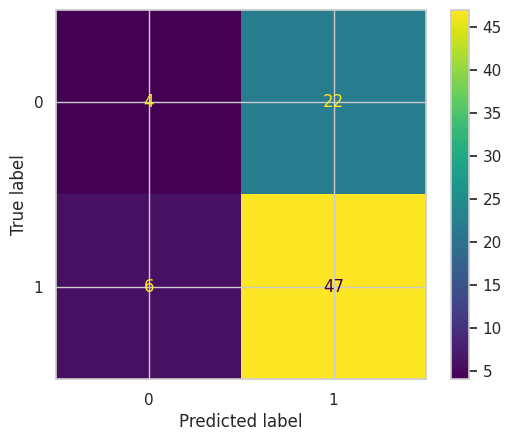

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test_clf,
    log_pred
)
plt.show()

In [ ]:
x_clf=df[early_features]
y_clf=df["pass_fail"]
x_train_clf,x_test_clf,y_train_clf,y_test_clf=train_test_split(
    x_clf,
    y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf
)
print(x_train_clf.shape)
print(x_test_clf.shape)

(316, 30)
(79, 30)


In [ ]:
preprocessor.fit(x_train_clf)
x_train_processed=preprocessor.transform(x_train_clf)
x_test_processed=preprocessor.transform(x_test_clf)

In [ ]:


tree_clf = DecisionTreeClassifier(
    random_state=42
)

tree_clf.fit(
    x_train_processed,
    y_train_clf
)

tree_pred = tree_clf.predict(
    x_test_processed
)

tree_prob = tree_clf.predict_proba(
    x_test_processed
)[:,1]

In [ ]:
print("Decision Tree")
print("-" * 40)

print("Accuracy :", round(accuracy_score(y_test_clf, tree_pred), 3))
print("Precision:", round(precision_score(y_test_clf, tree_pred, zero_division=0), 3))
print("Recall   :", round(recall_score(y_test_clf, tree_pred, zero_division=0), 3))
print("F1       :", round(f1_score(y_test_clf, tree_pred, zero_division=0), 3))
print("ROC-AUC  :", round(roc_auc_score(y_test_clf, tree_prob), 3))

Decision Tree
----------------------------------------
Accuracy : 0.582
Precision: 0.708
Recall   : 0.642
F1       : 0.673
ROC-AUC  : 0.552


In [ ]:


rf_clf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf_clf.fit(
    x_train_processed,
    y_train_clf
)

rf_clf_pred = rf_clf.predict(
    x_test_processed
)

rf_clf_prob = rf_clf.predict_proba(
    x_test_processed
)[:, 1]

print("Random Forest Classifier prediction completed!")

Random Forest Classifier prediction completed!


In [ ]:
print("Random Forest Classifier")
print("-" * 40)

print("Accuracy :", round(accuracy_score(y_test_clf, rf_clf_pred), 3))
print("Precision:", round(precision_score(y_test_clf, rf_clf_pred, zero_division=0), 3))
print("Recall   :", round(recall_score(y_test_clf, rf_clf_pred, zero_division=0), 3))
print("F1       :", round(f1_score(y_test_clf, rf_clf_pred, zero_division=0), 3))
print("ROC-AUC  :", round(roc_auc_score(y_test_clf, rf_clf_prob), 3))

Random Forest Classifier
----------------------------------------
Accuracy : 0.658
Precision: 0.691
Recall   : 0.887
F1       : 0.777
ROC-AUC  : 0.622


In [ ]:


print("Random Forest Classification Report")
print("-" * 50)

print(
    classification_report(
        y_test_clf,
        rf_clf_pred,
        target_names=["Fail", "Pass"],
        zero_division=0
    )
)

Random Forest Classification Report
--------------------------------------------------
              precision    recall  f1-score   support

        Fail       0.45      0.19      0.27        26
        Pass       0.69      0.89      0.78        53

    accuracy                           0.66        79
   macro avg       0.57      0.54      0.52        79
weighted avg       0.61      0.66      0.61        79



Confusion Matrix:
[[ 5 21]
 [ 6 47]]


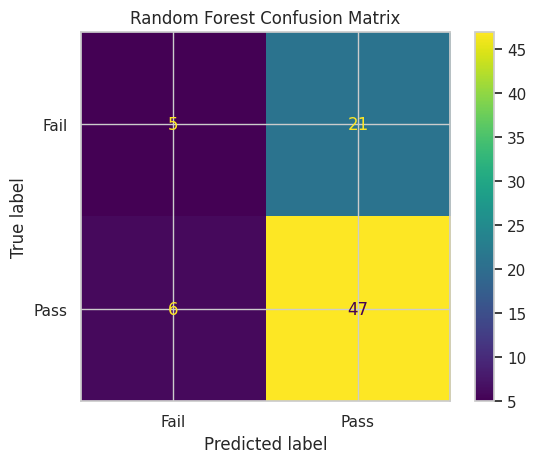

In [ ]:


cm = confusion_matrix(y_test_clf, rf_clf_pred)

print("Confusion Matrix:")
print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fail", "Pass"]
).plot()

plt.title("Random Forest Confusion Matrix")
plt.show()

In [ ]:
feature_names=preprocessor.get_feature_names_out()
feature_importance_df=pd.DataFrame({
    "feature":feature_names,
    "importance":rf_clf.feature_importances_
})
feature_importance_df=feature_importance_df.sort_values(
    by="importance",
    ascending=False
)
feature_importance_df.head(15)

,feature,importance
6,num__failures,0.097270
1,num__absences,0.092540
9,num__goout,0.054008
0,num__age,0.048406
8,num__freetime,0.038702
3,num__Fedu,0.038279
12,num__health,0.037453
2,num__Medu,0.036753
7,num__famrel,0.036152
11,num__Walc,0.034561


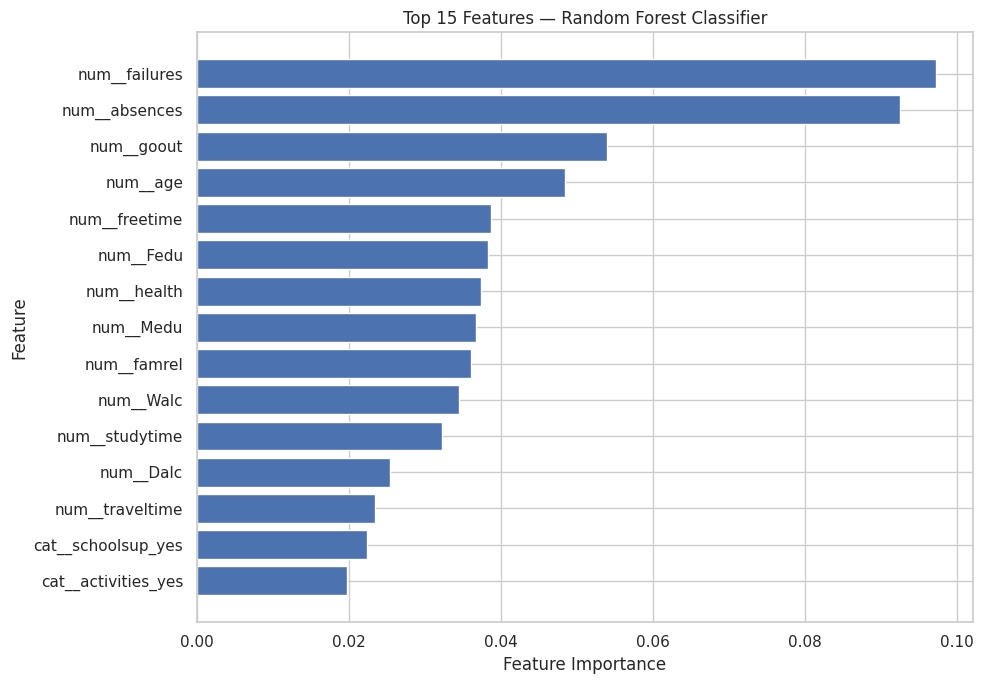

In [ ]:


top_features = feature_importance_df.head(15).sort_values(
    by="importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features — Random Forest Classifier")

plt.tight_layout()
plt.show()

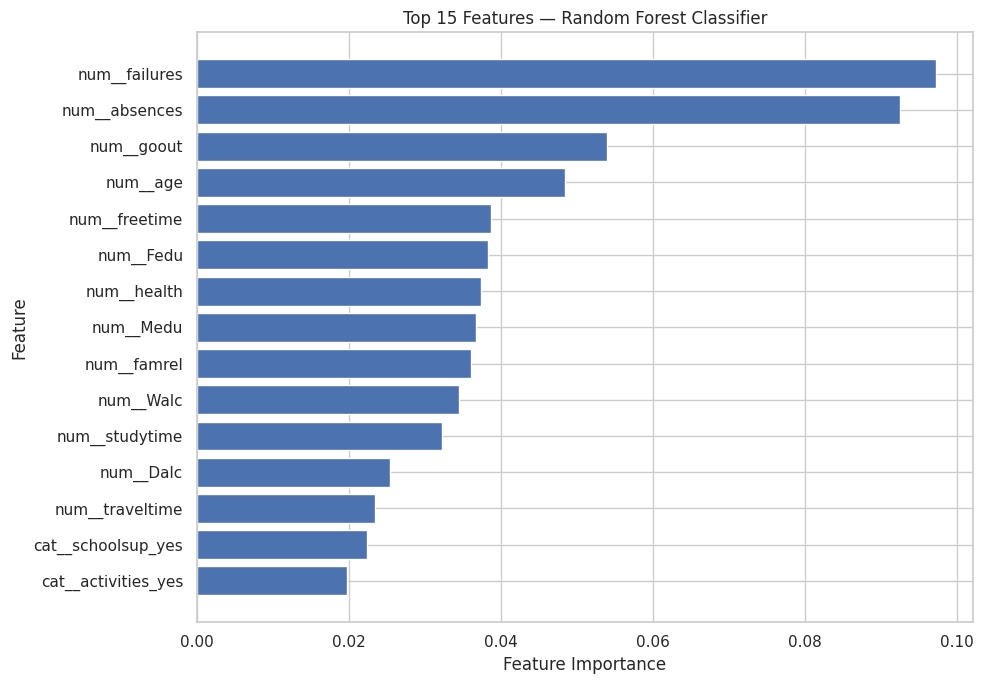

In [ ]:
plt.figure(figsize=(10, 7))

top_features = feature_importance_df.head(15).sort_values(
    by="importance"
)

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features — Random Forest Classifier")

plt.tight_layout()

plt.savefig(
    "/content/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
X_reg_later = df[later_features]
y_reg_later = df["G3"]

X_train_reg_later, X_test_reg_later, y_train_reg_later, y_test_reg_later = train_test_split(
    X_reg_later,
    y_reg_later,
    test_size=0.2,
    random_state=42
)

print("Training:", X_train_reg_later.shape)
print("Testing :", X_test_reg_later.shape)

Training: (316, 32)
Testing : (79, 32)


In [ ]:


numeric_features_later = numerical_features + ["G1", "G2"]

categorical_features_later = categorical_features

numeric_transformer_later = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_transformer_later = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            drop="if_binary"
        ))
    ]
)

preprocessor_later = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_later, numeric_features_later),
        ("cat", categorical_transformer_later, categorical_features_later)
    ]
)

print("Numeric features:", len(numeric_features_later))
print("Categorical features:", len(categorical_features_later))

Numeric features: 15
Categorical features: 17


In [ ]:
preprocessor_later.fit(X_train_reg_later)

X_train_later_processed = preprocessor_later.transform(
    X_train_reg_later
)

X_test_later_processed = preprocessor_later.transform(
    X_test_reg_later
)

print("Processed training:", X_train_later_processed.shape)
print("Processed testing :", X_test_later_processed.shape)

Processed training: (316, 45)
Processed testing : (79, 45)


In [ ]:


rf_reg_later = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf_reg_later.fit(
    X_train_later_processed,
    y_train_reg_later
)

rf_reg_later_pred = rf_reg_later.predict(
    X_test_later_processed
)

print("Later-term Random Forest regression completed!")

Later-term Random Forest regression completed!


In [ ]:
mae_later = mean_absolute_error(
    y_test_reg_later,
    rf_reg_later_pred
)

rmse_later = mean_squared_error(
    y_test_reg_later,
    rf_reg_later_pred
) ** 0.5

r2_later = r2_score(
    y_test_reg_later,
    rf_reg_later_pred
)

print("Later-Term Random Forest")
print("-" * 40)
print("MAE :", round(mae_later, 3))
print("RMSE:", round(rmse_later, 3))
print("R²  :", round(r2_later, 3))

Later-Term Random Forest
----------------------------------------
MAE : 1.187
RMSE: 1.995
R²  : 0.806


In [ ]:
X_clf_later = df[later_features]
y_clf_later = df["pass_fail"]

X_train_clf_later, X_test_clf_later, y_train_clf_later, y_test_clf_later = train_test_split(
    X_clf_later,
    y_clf_later,
    test_size=0.2,
    random_state=42,
    stratify=y_clf_later
)

print("Training:", X_train_clf_later.shape)
print("Testing :", X_test_clf_later.shape)

Training: (316, 32)
Testing : (79, 32)


In [ ]:
preprocessor_later.fit(X_train_clf_later)

X_train_clf_later_processed = preprocessor_later.transform(
    X_train_clf_later
)

X_test_clf_later_processed = preprocessor_later.transform(
    X_test_clf_later
)

print(
    "Processed training:",
    X_train_clf_later_processed.shape
)

print(
    "Processed testing :",
    X_test_clf_later_processed.shape
)

Processed training: (316, 45)
Processed testing : (79, 45)


In [ ]:


rf_clf_later = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf_clf_later.fit(
    X_train_clf_later_processed,
    y_train_clf_later
)

rf_clf_later_pred = rf_clf_later.predict(
    X_test_clf_later_processed
)

rf_clf_later_prob = rf_clf_later.predict_proba(
    X_test_clf_later_processed
)[:, 1]

print("Later-term Random Forest classification completed!")

Later-term Random Forest classification completed!


In [ ]:


print("Later-Term Random Forest Classifier")
print("-" * 45)

print(
    "Accuracy :",
    round(accuracy_score(y_test_clf_later, rf_clf_later_pred), 3)
)

print(
    "Precision:",
    round(precision_score(y_test_clf_later, rf_clf_later_pred, zero_division=0), 3)
)

print(
    "Recall   :",
    round(recall_score(y_test_clf_later, rf_clf_later_pred, zero_division=0), 3)
)

print(
    "F1       :",
    round(f1_score(y_test_clf_later, rf_clf_later_pred, zero_division=0), 3)
)

print(
    "ROC-AUC  :",
    round(roc_auc_score(y_test_clf_later, rf_clf_later_prob), 3)
)

Later-Term Random Forest Classifier
---------------------------------------------
Accuracy : 0.873
Precision: 0.957
Recall   : 0.849
F1       : 0.9
ROC-AUC  : 0.935


In [ ]:


print("Later-Term Random Forest Classification Report")
print("-" * 55)

print(
    classification_report(
        y_test_clf_later,
        rf_clf_later_pred,
        target_names=["Fail", "Pass"],
        zero_division=0
    )
)

Later-Term Random Forest Classification Report
-------------------------------------------------------
              precision    recall  f1-score   support

        Fail       0.75      0.92      0.83        26
        Pass       0.96      0.85      0.90        53

    accuracy                           0.87        79
   macro avg       0.85      0.89      0.86        79
weighted avg       0.89      0.87      0.88        79



In [ ]:


cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rf_cv = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

cv_results = cross_validate(
    rf_cv,
    x_train_processed,
    y_train_clf,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc"
    ]
)

print("5-Fold Cross-Validation — Early Warning Random Forest")
print("-" * 60)

for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    scores = cv_results[f"test_{metric}"]

    print(
        f"{metric.upper():10s}: "
        f"Mean = {scores.mean():.3f}, "
        f"Std = {scores.std():.3f}"
    )

5-Fold Cross-Validation — Early Warning Random Forest
------------------------------------------------------------
ACCURACY  : Mean = 0.700, Std = 0.046
PRECISION : Mean = 0.716, Std = 0.030
RECALL    : Mean = 0.915, Std = 0.035
F1        : Mean = 0.803, Std = 0.030
ROC_AUC   : Mean = 0.687, Std = 0.064


In [ ]:

y_risk = (df["G3"] < 10).astype(int)

x_risk = df[early_features]

x_train_risk, x_test_risk, y_train_risk, y_test_risk = train_test_split(
    x_risk,
    y_risk,
    test_size=0.2,
    random_state=42,
    stratify=y_risk
)


preprocessor_risk = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"),
         categorical_features)
    ]
)

x_train_risk_processed = preprocessor_risk.fit_transform(x_train_risk)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rf_risk_cv = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

risk_cv_results = cross_validate(
    rf_risk_cv,
    x_train_risk_processed,
    y_train_risk,
    cv=cv,
    scoring=["accuracy", "precision", "recall", "f1", "roc_auc"]
)

print("5-Fold Cross-Validation — Early Warning / At-Risk")
print("-" * 60)

for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    scores = risk_cv_results[f"test_{metric}"]

    print(
        f"{metric.upper():10s}: "
        f"Mean = {scores.mean():.3f}, "
        f"Std = {scores.std():.3f}"
    )

5-Fold Cross-Validation — Early Warning / At-Risk
------------------------------------------------------------
ACCURACY  : Mean = 0.696, Std = 0.040
PRECISION : Mean = 0.677, Std = 0.202
RECALL    : Mean = 0.241, Std = 0.072
F1        : Mean = 0.338, Std = 0.074
ROC_AUC   : Mean = 0.656, Std = 0.055


In [ ]:

preprocessor_cv = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(
            handle_unknown="ignore",
            drop="if_binary"
        ), categorical_features)
    ]
)
rf_cv_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_cv),
        ("model", RandomForestClassifier(
            n_estimators=300,
            random_state=42
        ))
    ]
)

print("Pipeline created successfully.")

Pipeline created successfully.


In [ ]:

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

risk_cv_results = cross_validate(
    rf_cv_pipeline,
    x_train_risk,
    y_train_risk,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc"
    ]
)

print("Proper 5-Fold Cross-Validation — Early Warning / At-Risk")
print("-" * 65)

for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    scores = risk_cv_results[f"test_{metric}"]

    print(
        f"{metric.upper():10s}: "
        f"Mean = {scores.mean():.3f}, "
        f"Std = {scores.std():.3f}"
    )

Proper 5-Fold Cross-Validation — Early Warning / At-Risk
-----------------------------------------------------------------
ACCURACY  : Mean = 0.693, Std = 0.039
PRECISION : Mean = 0.664, Std = 0.204
RECALL    : Mean = 0.232, Std = 0.081
F1        : Mean = 0.325, Std = 0.085
ROC_AUC   : Mean = 0.655, Std = 0.055


In [ ]:

rf_cv_pipeline.fit(x_train_risk, y_train_risk)

fitted_preprocessor = rf_cv_pipeline.named_steps["preprocessor"]

fitted_rf = rf_cv_pipeline.named_steps["model"]

feature_names = fitted_preprocessor.get_feature_names_out()

print("Number of processed features:", len(feature_names))
print("\nFirst 20 processed features:")
print(feature_names[:20])

Number of processed features: 43

First 20 processed features:
['num__age' 'num__absences' 'num__Medu' 'num__Fedu' 'num__traveltime'
 'num__studytime' 'num__failures' 'num__famrel' 'num__freetime'
 'num__goout' 'num__Dalc' 'num__Walc' 'num__health' 'cat__school_MS'
 'cat__sex_M' 'cat__address_U' 'cat__famsize_LE3' 'cat__Pstatus_T'
 'cat__Mjob_at_home' 'cat__Mjob_health']


In [ ]:

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": fitted_rf.feature_importances_
})

feature_importance_df = feature_importance_df.sort_values(
    by="importance",
    ascending=False
).reset_index(drop=True)

print("Top 15 Features — Early Warning Random Forest")
print("-" * 60)

print(
    feature_importance_df.head(15).to_string(index=False)
)

Top 15 Features — Early Warning Random Forest
------------------------------------------------------------
           feature  importance
     num__absences    0.087835
     num__failures    0.071934
        num__goout    0.051936
          num__age    0.049534
         num__Fedu    0.041702
       num__health    0.041042
         num__Medu    0.040593
     num__freetime    0.039927
       num__famrel    0.039238
         num__Walc    0.038480
    num__studytime    0.030398
         num__Dalc    0.027425
   num__traveltime    0.024042
cat__schoolsup_yes    0.023161
 cat__romantic_yes    0.021851


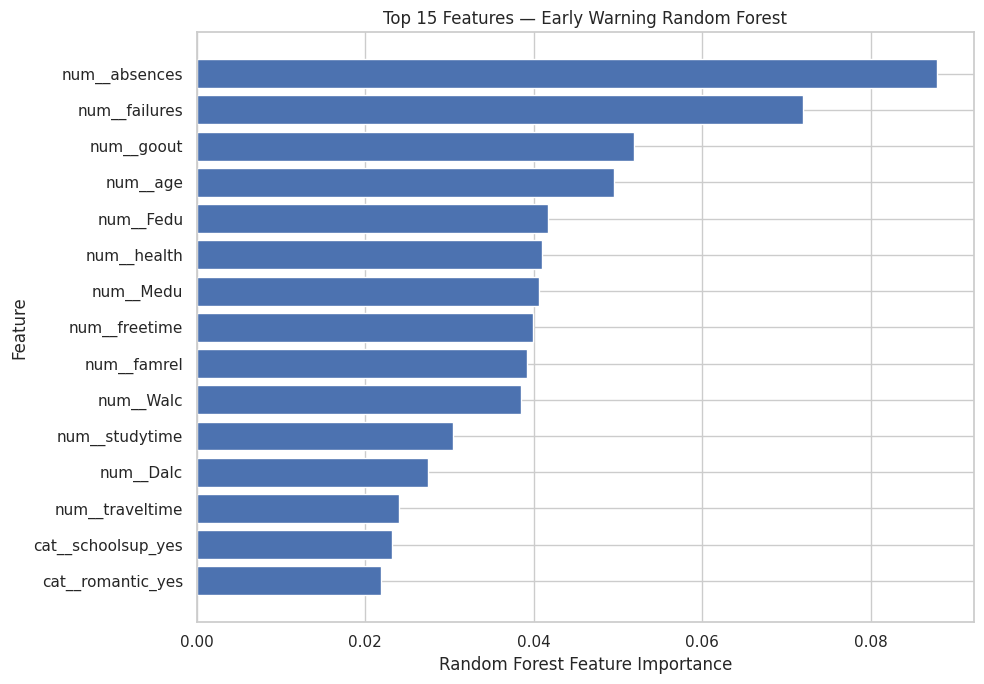

In [ ]:

top_features = (
    feature_importance_df
    .head(15)
    .sort_values("importance")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Random Forest Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features — Early Warning Random Forest")

plt.tight_layout()

plt.savefig(
    "/content/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
from sklearn.inspection import permutation_importance
perm_result = permutation_importance(
    rf_cv_pipeline,
    x_test_risk,
    y_test_risk,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42
)

permutation_df = pd.DataFrame({
    "feature": x_test_risk.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
})

permutation_df = permutation_df.sort_values(
    by="importance_mean",
    ascending=False
).reset_index(drop=True)

print("Top 15 Features — Permutation Importance")
print("-" * 65)

print(
    permutation_df.head(15).to_string(index=False)
)

Top 15 Features — Permutation Importance
-----------------------------------------------------------------
   feature  importance_mean  importance_std
  failures         0.102032        0.032980
  absences         0.020755        0.035677
 schoolsup         0.019775        0.014856
 studytime         0.013679        0.006356
     goout         0.013534        0.025713
  guardian         0.010123        0.012774
  freetime         0.008454        0.005614
       sex         0.004064        0.009578
    higher         0.003955        0.004410
   nursery         0.001996        0.004128
   address         0.001089        0.010798
traveltime         0.000073        0.003850
   famsize        -0.000290        0.003606
  romantic        -0.001306        0.012216
    reason        -0.001887        0.010591


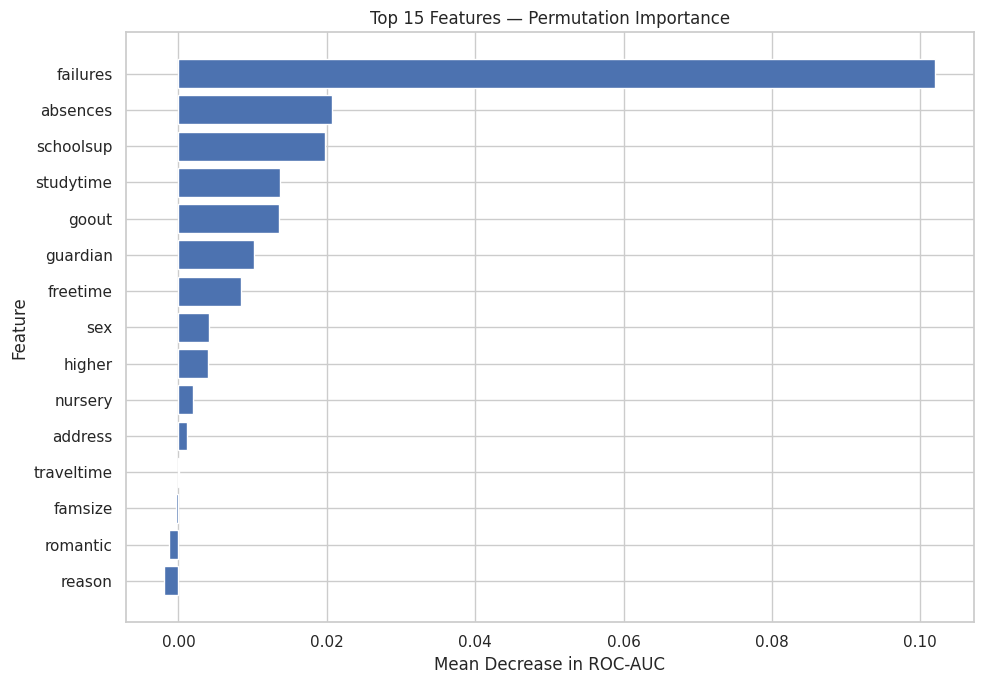

In [ ]:

top_perm = (
    permutation_df
    .head(15)
    .sort_values("importance_mean")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_perm["feature"],
    top_perm["importance_mean"]
)

plt.xlabel("Mean Decrease in ROC-AUC")
plt.ylabel("Feature")
plt.title("Top 15 Features — Permutation Importance")

plt.tight_layout()
plt.savefig(
    "/content/permutation_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:

risk_test_pred = rf_cv_pipeline.predict(x_test_risk)
fairness_df = x_test_risk.copy()

fairness_df["actual_fail"] = y_test_risk
fairness_df["predicted_fail"] = risk_test_pred

print("Test-set predictions created successfully.")
print("Number of test students:", len(fairness_df))

Test-set predictions created successfully.
Number of test students: 79


In [ ]:


sex_results = []

for group in sorted(fairness_df["sex"].unique()):

    group_data = fairness_df[fairness_df["sex"] == group]

    actual_failures = group_data["actual_fail"].sum()

    if actual_failures > 0:
        fail_recall = recall_score(
            group_data["actual_fail"],
            group_data["predicted_fail"],
            pos_label=1
        )
    else:
        fail_recall = float("nan")

    sex_results.append({
        "sex": group,
        "students": len(group_data),
        "actual_fail": int(actual_failures),
        "fail_recall": fail_recall
    })

sex_fairness = pd.DataFrame(sex_results)

print("Fail Recall by Sex")
print("-" * 50)
print(sex_fairness.to_string(index=False))

Fail Recall by Sex
--------------------------------------------------
sex  students  actual_fail  fail_recall
  F        43           17     0.176471
  M        36            9     0.555556


In [ ]:


school_results = []

for group in sorted(fairness_df["school"].unique()):

    group_data = fairness_df[fairness_df["school"] == group]

    actual_failures = group_data["actual_fail"].sum()

    if actual_failures > 0:
        fail_recall = recall_score(
            group_data["actual_fail"],
            group_data["predicted_fail"],
            pos_label=1
        )
    else:
        fail_recall = float("nan")

    school_results.append({
        "school": group,
        "students": len(group_data),
        "actual_fail": int(actual_failures),
        "fail_recall": fail_recall
    })

school_fairness = pd.DataFrame(school_results)

print("Fail Recall by School")
print("-" * 50)
print(school_fairness.to_string(index=False))

Fail Recall by School
--------------------------------------------------
school  students  actual_fail  fail_recall
    GP        69           23     0.260870
    MS        10            3     0.666667


In [ ]:


address_results = []

for group in sorted(fairness_df["address"].unique()):

    group_data = fairness_df[fairness_df["address"] == group]

    actual_failures = group_data["actual_fail"].sum()

    if actual_failures > 0:
        fail_recall = recall_score(
            group_data["actual_fail"],
            group_data["predicted_fail"],
            pos_label=1
        )
    else:
        fail_recall = float("nan")

    address_results.append({
        "address": group,
        "students": len(group_data),
        "actual_fail": int(actual_failures),
        "fail_recall": fail_recall
    })

address_fairness = pd.DataFrame(address_results)

print("Fail Recall by Address")
print("-" * 50)
print(address_fairness.to_string(index=False))

Fail Recall by Address
--------------------------------------------------
address  students  actual_fail  fail_recall
      R        20            7     0.714286
      U        59           19     0.157895


In [ ]:


sex_fairness_display = sex_fairness.copy()
sex_fairness_display["group_type"] = "Sex"
sex_fairness_display["group"] = sex_fairness_display["sex"]

school_fairness_display = school_fairness.copy()
school_fairness_display["group_type"] = "School"
school_fairness_display["group"] = school_fairness_display["school"]

address_fairness_display = address_fairness.copy()
address_fairness_display["group_type"] = "Address"
address_fairness_display["group"] = address_fairness_display["address"]

fairness_summary = pd.concat([
    sex_fairness_display[
        ["group_type", "group", "students", "actual_fail", "fail_recall"]
    ],
    school_fairness_display[
        ["group_type", "group", "students", "actual_fail", "fail_recall"]
    ],
    address_fairness_display[
        ["group_type", "group", "students", "actual_fail", "fail_recall"]
    ]
], ignore_index=True)

print("Fairness Summary — Fail Recall")
print("-" * 65)
print(fairness_summary.to_string(index=False))


Fairness Summary — Fail Recall
-----------------------------------------------------------------
group_type group  students  actual_fail  fail_recall
       Sex     F        43           17     0.176471
       Sex     M        36            9     0.555556
    School    GP        69           23     0.260870
    School    MS        10            3     0.666667
   Address     R        20            7     0.714286
   Address     U        59           19     0.157895


In [ ]:

fairness_summary["fail_fnr"] = 1 - fairness_summary["fail_recall"]

prediction_rates = []

for _, row in fairness_summary.iterrows():
    group_type = row["group_type"]
    group = row["group"]

    group_data = fairness_df[
        (
            ((fairness_df["sex"] == group) if group_type == "Sex" else
             (fairness_df["school"] == group) if group_type == "School" else
             (fairness_df["address"] == group))
        )
    ]

    predicted_fail_rate = group_data["predicted_fail"].mean()

    prediction_rates.append(predicted_fail_rate)

fairness_summary["predicted_fail_rate"] = prediction_rates

print("Fairness Summary")
print("-" * 80)

print(
    fairness_summary[
        [
            "group_type",
            "group",
            "students",
            "actual_fail",
            "fail_recall",
            "fail_fnr",
            "predicted_fail_rate"
        ]
    ].to_string(index=False)
)

Fairness Summary
--------------------------------------------------------------------------------
group_type group  students  actual_fail  fail_recall  fail_fnr  predicted_fail_rate
       Sex     F        43           17     0.176471  0.823529             0.139535
       Sex     M        36            9     0.555556  0.444444             0.166667
    School    GP        69           23     0.260870  0.739130             0.130435
    School    MS        10            3     0.666667  0.333333             0.300000
   Address     R        20            7     0.714286  0.285714             0.300000
   Address     U        59           19     0.157895  0.842105             0.101695


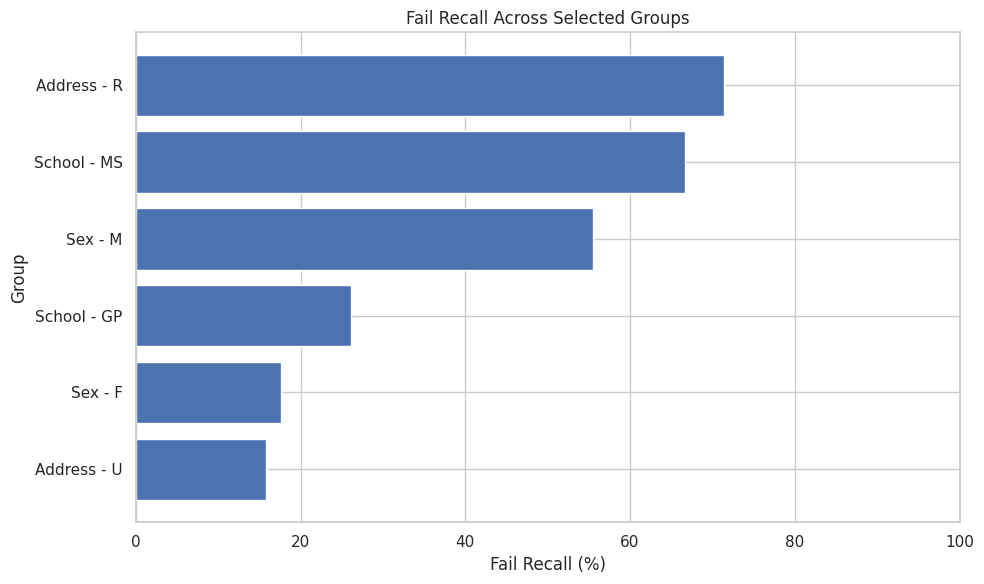

In [ ]:

fairness_plot = fairness_summary.copy()

fairness_plot["label"] = (
    fairness_plot["group_type"]
    + " - "
    + fairness_plot["group"].astype(str)
)

fairness_plot["fail_recall_percent"] = (
    fairness_plot["fail_recall"] * 100
)

fairness_plot = fairness_plot.sort_values(
    "fail_recall_percent"
)

plt.figure(figsize=(10, 6))

plt.barh(
    fairness_plot["label"],
    fairness_plot["fail_recall_percent"]
)

plt.xlabel("Fail Recall (%)")
plt.ylabel("Group")
plt.title("Fail Recall Across Selected Groups")

plt.xlim(0, 100)
plt.tight_layout()

plt.savefig(
    "/content/fairness_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:


X_fair_cv = df[early_features]
y_fair_cv = y_risk

cv_fairness = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

fairness_cv_results = []

for fold, (train_idx, val_idx) in enumerate(
    cv_fairness.split(X_fair_cv, y_fair_cv),
    start=1
):

    X_train_fold = X_fair_cv.iloc[train_idx]
    X_val_fold = X_fair_cv.iloc[val_idx]

    y_train_fold = y_fair_cv.iloc[train_idx]
    y_val_fold = y_fair_cv.iloc[val_idx]

    fold_model = clone(rf_cv_pipeline)

    fold_model.fit(X_train_fold, y_train_fold)

    y_val_pred = fold_model.predict(X_val_fold)

    for group in sorted(X_val_fold["sex"].unique()):

        group_mask = X_val_fold["sex"] == group

        y_group_actual = y_val_fold[group_mask]
        y_group_pred = y_val_pred[group_mask]

        actual_fail = (y_group_actual == 1).sum()

        if actual_fail > 0:
            recall = recall_score(
                y_group_actual,
                y_group_pred,
                pos_label=1
            )
        else:
            recall = float("nan")

        fairness_cv_results.append({
            "fold": fold,
            "sex": group,
            "students": group_mask.sum(),
            "actual_fail": actual_fail,
            "fail_recall": recall
        })

fairness_cv_df = pd.DataFrame(fairness_cv_results)

print("5-Fold Cross-Validation — Fail Recall by Sex")
print("-" * 70)

print(fairness_cv_df.to_string(index=False))

5-Fold Cross-Validation — Fail Recall by Sex
----------------------------------------------------------------------
 fold sex  students  actual_fail  fail_recall
    1   F        41           14     0.142857
    1   M        38           12     0.083333
    2   F        39           14     0.357143
    2   M        40           12     0.333333
    3   F        46           17     0.117647
    3   M        33            9     0.333333
    4   F        42           16     0.187500
    4   M        37           10     0.300000
    5   F        40           14     0.142857
    5   M        39           12     0.500000


In [ ]:


sex_cv_summary = (
    fairness_cv_df
    .groupby("sex")["fail_recall"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

print("5-Fold Cross-Validation Summary — Fail Recall by Sex")
print("-" * 65)

print(sex_cv_summary.to_string(index=False))

print("\nOverall mean Fail Recall by sex:")
for _, row in sex_cv_summary.iterrows():
    print(
        f"{row['sex']}: "
        f"{row['mean']:.3f} ± {row['std']:.3f}"
    )


5-Fold Cross-Validation Summary — Fail Recall by Sex
-----------------------------------------------------------------
sex     mean      std  count
  F 0.189601 0.096982      5
  M 0.310000 0.148885      5

Overall mean Fail Recall by sex:
F: 0.190 ± 0.097
M: 0.310 ± 0.149


In [ ]:


school_cv_results = []

for fold, (train_idx, val_idx) in enumerate(
    cv_fairness.split(x_train_risk, y_train_risk), start=1
):
    X_train_fold = x_train_risk.iloc[train_idx]
    X_val_fold = x_train_risk.iloc[val_idx]

    y_train_fold = y_train_risk.iloc[train_idx]
    y_val_fold = y_train_risk.iloc[val_idx]

    model = clone(rf_cv_pipeline)

    model.fit(X_train_fold, y_train_fold)

    y_pred_fold = model.predict(X_val_fold)

    temp = X_val_fold[["school"]].copy()
    temp["actual_fail"] = y_val_fold.values
    temp["predicted_fail"] = y_pred_fold

    for school_group in temp["school"].unique():
        group_data = temp[temp["school"] == school_group]

        actual_fail = group_data["actual_fail"].sum()

        if actual_fail > 0:
            fail_recall = (
                (
                    (group_data["actual_fail"] == 1)
                    & (group_data["predicted_fail"] == 1)
                ).sum()
                / actual_fail
            )
        else:
            fail_recall = float("nan")

        school_cv_results.append({
            "fold": fold,
            "school": school_group,
            "students": len(group_data),
            "actual_fail": actual_fail,
            "fail_recall": fail_recall
        })

school_cv_df = pd.DataFrame(school_cv_results)

print("5-Fold Cross-Validation — Fail Recall by School")
print("-" * 65)
print(school_cv_df.to_string(index=False))

5-Fold Cross-Validation — Fail Recall by School
-----------------------------------------------------------------
 fold school  students  actual_fail  fail_recall
    1     GP        59           18     0.111111
    1     MS         5            3     0.333333
    2     GP        57           16     0.375000
    2     MS         6            4     0.250000
    3     GP        56           19     0.105263
    3     MS         7            2     0.500000
    4     GP        56           18     0.277778
    4     MS         7            3     0.333333
    5     GP        52           19     0.263158
    5     MS        11            2     0.000000


In [ ]:
print(x_train_risk.shape)
print(y_train_risk.shape)
print(x_train_risk[["address"]].head())

(316, 30)
(316,)
    address
101       U
63        U
245       U
112       U
8         U


In [ ]:


y_risk = (df["G3"] < 10).astype(int)

X_risk = df[early_features]

X_train_risk, X_test_risk, y_train_risk, y_test_risk = train_test_split(
    X_risk,
    y_risk,
    test_size=0.2,
    random_state=42,
    stratify=y_risk
)

print("X_train_risk shape:", X_train_risk.shape)
print("X_test_risk shape:", X_test_risk.shape)
print("y_train_risk shape:", y_train_risk.shape)
print("y_test_risk shape:", y_test_risk.shape)

X_train_risk shape: (316, 30)
X_test_risk shape: (79, 30)
y_train_risk shape: (316,)
y_test_risk shape: (79,)


In [ ]:


from sklearn.base import clone

address_cv_results = []

for fold, (train_idx, val_idx) in enumerate(
    cv_fairness.split(X_train_risk, y_train_risk), start=1
):
    X_train_fold = X_train_risk.iloc[train_idx]
    X_val_fold = X_train_risk.iloc[val_idx]

    y_train_fold = y_train_risk.iloc[train_idx]
    y_val_fold = y_train_risk.iloc[val_idx]

    model = clone(rf_cv_pipeline)

    model.fit(X_train_fold, y_train_fold)

    y_pred_fold = model.predict(X_val_fold)

    temp = X_val_fold[["address"]].copy()
    temp["actual_fail"] = y_val_fold.values
    temp["predicted_fail"] = y_pred_fold

    for address_group in temp["address"].unique():

        group_data = temp[temp["address"] == address_group]

        actual_fail = group_data["actual_fail"].sum()

        if actual_fail > 0:
            fail_recall = (
                (
                    (group_data["actual_fail"] == 1)
                    & (group_data["predicted_fail"] == 1)
                ).sum()
                / actual_fail
            )
        else:
            fail_recall = float("nan")

        address_cv_results.append({
            "fold": fold,
            "address": address_group,
            "students": len(group_data),
            "actual_fail": actual_fail,
            "fail_recall": fail_recall
        })

address_cv_df = pd.DataFrame(address_cv_results)

print("5-Fold Cross-Validation — Fail Recall by Address")
print("-" * 65)
print(address_cv_df.to_string(index=False))

5-Fold Cross-Validation — Fail Recall by Address
-----------------------------------------------------------------
 fold address  students  actual_fail  fail_recall
    1       U        51           16     0.125000
    1       R        13            5     0.200000
    2       U        53           15     0.400000
    2       R        10            5     0.200000
    3       U        46           14     0.071429
    3       R        17            7     0.285714
    4       U        51           18     0.277778
    4       R        12            3     0.333333
    5       U        47           15     0.266667
    5       R        16            6     0.166667


In [ ]:
print("RESPONSIBLE MODELING — EARLY-WARNING RISK MODEL")
print("=" * 65)

print(f"Overall Fail Recall: "
      f"{risk_cv_results['test_recall'].mean():.3f} "
      f"± {risk_cv_results['test_recall'].std():.3f}")

print(f"Overall Fail F1: "
      f"{risk_cv_results['test_f1'].mean():.3f} "
      f"± {risk_cv_results['test_f1'].std():.3f}")

print(f"ROC-AUC: "
      f"{risk_cv_results['test_roc_auc'].mean():.3f} "
      f"± {risk_cv_results['test_roc_auc'].std():.3f}")

print("\nKey interpretation:")
print(
    "The model identifies only a limited proportion of students "
    "who actually fail, so predictions should not be treated as "
    "definitive labels or decisions about individual students."
)

RESPONSIBLE MODELING — EARLY-WARNING RISK MODEL
Overall Fail Recall: 0.232 ± 0.081
Overall Fail F1: 0.325 ± 0.085
ROC-AUC: 0.655 ± 0.055

Key interpretation:
The model identifies only a limited proportion of students who actually fail, so predictions should not be treated as definitive labels or decisions about individual students.


In [ ]:


final_results = pd.DataFrame([
    {
        "Task": "Regression",
        "Scenario": "Early Warning",
        "Model": "Random Forest",
        "MAE": 2.989,
        "RMSE": 3.760,
        "R2": 0.310,
        "Accuracy": None,
        "ROC_AUC": None,
        "Fail_Recall": None,
        "Fail_F1": None
    },
    {
        "Task": "Regression",
        "Scenario": "Later Term (G1 + G2)",
        "Model": "Random Forest",
        "MAE": 1.187,
        "RMSE": 1.995,
        "R2": 0.806,
        "Accuracy": None,
        "ROC_AUC": None,
        "Fail_Recall": None,
        "Fail_F1": None
    },
    {
        "Task": "Classification",
        "Scenario": "Early Warning",
        "Model": "Random Forest",
        "MAE": None,
        "RMSE": None,
        "R2": None,
        "Accuracy": 0.658,
        "ROC_AUC": 0.622,
        "Fail_Recall": 0.192,
        "Fail_F1": 0.270
    },
    {
        "Task": "Classification",
        "Scenario": "Later Term (G1 + G2)",
        "Model": "Random Forest",
        "MAE": None,
        "RMSE": None,
        "R2": None,
        "Accuracy": 0.873,
        "ROC_AUC": 0.935,
        "Fail_Recall": 0.920,
        "Fail_F1": 0.830
    },
    {
        "Task": "Classification",
        "Scenario": "Early Warning — 5-Fold CV",
        "Model": "Random Forest",
        "MAE": None,
        "RMSE": None,
        "R2": None,
        "Accuracy": 0.693,
        "ROC_AUC": 0.655,
        "Fail_Recall": 0.232,
        "Fail_F1": 0.325
    }
])

print("FINAL MODEL RESULTS")
print("=" * 100)

display(final_results)

FINAL MODEL RESULTS


,Task,Scenario,Model,MAE,RMSE,R2,Accuracy,ROC_AUC,Fail_Recall,Fail_F1
0,Regression,Early Warning,Random Forest,2.989,3.760,0.310,NaN,NaN,NaN,NaN
1,Regression,Later Term (G1 + G2),Random Forest,1.187,1.995,0.806,NaN,NaN,NaN,NaN
2,Classification,Early Warning,Random Forest,NaN,NaN,NaN,0.658,0.622,0.192,0.270
3,Classification,Later Term (G1 + G2),Random Forest,NaN,NaN,NaN,0.873,0.935,0.920,0.830
4,Classification,Early Warning — 5-Fold CV,Random Forest,NaN,NaN,NaN,0.693,0.655,0.232,0.325


In [ ]:


sex_summary = (
    fairness_cv_df
    .groupby("sex")["fail_recall"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

sex_summary["group_type"] = "Sex"
sex_summary = sex_summary.rename(columns={"sex": "group"})

school_summary = (
    school_cv_df
    .groupby("school")["fail_recall"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

school_summary["group_type"] = "School"
school_summary = school_summary.rename(columns={"school": "group"})

address_summary = (
    address_cv_df
    .groupby("address")["fail_recall"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

address_summary["group_type"] = "Address"
address_summary = address_summary.rename(columns={"address": "group"})

fairness_final = pd.concat(
    [
        sex_summary,
        school_summary,
        address_summary
    ],
    ignore_index=True
)

fairness_final = fairness_final[
    ["group_type", "group", "mean", "std", "count"]
]

fairness_final = fairness_final.rename(
    columns={
        "mean": "mean_fail_recall",
        "std": "std_fail_recall",
        "count": "folds"
    }
)

print("FINAL FAIRNESS SUMMARY")
print("=" * 75)

display(fairness_final.round(3))

FINAL FAIRNESS SUMMARY


,group_type,group,mean_fail_recall,std_fail_recall,folds
0,Sex,F,0.190,0.097,5
1,Sex,M,0.310,0.149,5
2,School,GP,0.226,0.116,5
3,School,MS,0.283,0.183,5
4,Address,R,0.237,0.070,5
5,Address,U,0.228,0.131,5


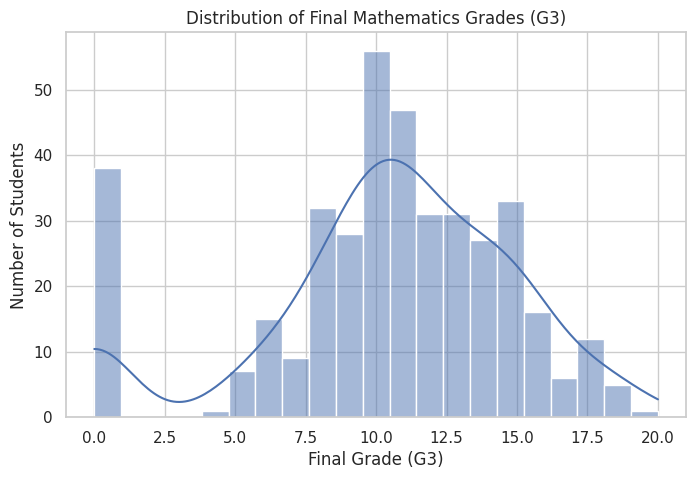

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(df["G3"], bins=21, kde=True)

plt.title("Distribution of Final Mathematics Grades (G3)")
plt.xlabel("Final Grade (G3)")
plt.ylabel("Number of Students")

plt.savefig("/content/grade_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

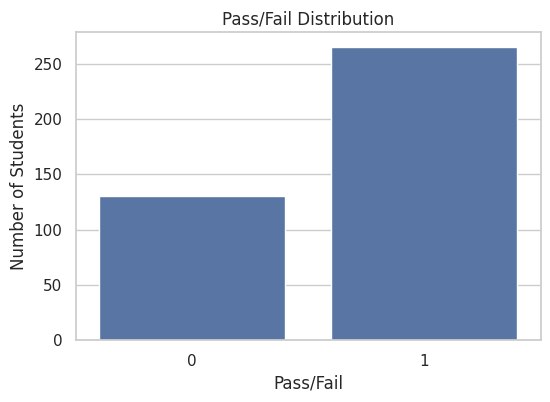

In [ ]:
plt.figure(figsize=(6, 4))

sns.countplot(x="pass_fail", data=df)

plt.title("Pass/Fail Distribution")
plt.xlabel("Pass/Fail")
plt.ylabel("Number of Students")

plt.savefig("/content/pass_fail_distribution.png", dpi=300, bbox_inches="tight")

plt.show()